In [1]:
import os
import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
if not os.path.exists('data/train.csv'):
    !kaggle competitions download -c playground-series-s6e7
    !unzip playground-series-s6e7.zip -d data
    !rm playground-series-s6e7.zip
    !kaggle datasets download ziya07/college-student-health-behavior-dataset
    !unzip college-student-health-behavior-dataset.zip -d data

In [3]:
from mllabs.processor import PolarsLoader
ploader = PolarsLoader(predefined_types={'id': pl.Int64, 'step_count': pl.Float32, 'student_id': pl.Categorical}, infer_schema_length=10000)
data_list = ['data/train.csv', 'data/test.csv', 'data/student_health_dataset_50k.csv']
ploader.fit(data_list)

PolarsLoader(infer_schema_length=10000,
             predefined_types={'id': Int64, 'step_count': Float32,
                               'student_id': Categorical})

In [4]:
df_type = ploader.df_type_.join(pd.Series(ploader.pl_type_, name='pl_dtype'))
df_type

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,pl_dtype
feature,,,,,,,,,,,
bmi,16.0,35.00,19854.0,1015987.0,1591.000000,Float64,True,True,True,True,Float32
calorie_expenditure,1200.0,3901.00,75505.0,960336.0,2116.666667,Float64,True,True,True,False,Float32
diet_type,NaN,NaN,9859.0,1025982.0,3.666667,String,False,False,False,False,Categorical
exercise_duration,0.0,120.00,9859.0,1025982.0,905.333333,Float64,True,True,True,True,Float32
gender,NaN,NaN,30533.0,1005308.0,3.666667,String,False,False,False,False,Categorical
health_condition,NaN,NaN,0.0,740088.0,3.000000,String,False,False,False,False,Categorical
heart_rate,50.0,120.00,11190.0,1024651.0,550.000000,Float64,True,True,True,True,Float32
id,0.0,985840.00,0.0,985841.0,492920.500000,Int64,True,True,False,False,Int64
physical_activity_level,NaN,NaN,52316.0,983525.0,3.666667,String,False,False,False,False,Categorical


In [5]:
from mllabs.processor import PandasConverter
pd_conv = PandasConverter(index_col = 'id')
df_train = ploader.transform(data_list[0:1])
pd_conv.fit(df_train)

PandasConverter(index_col='id')

In [6]:
df_train = pd_conv.transform(df_train)
df_train.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
0,unhealthy,5.22,70.599998,25.660000,2174.0,1326.0,19.799999,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.300003,25.840000,1966.0,9891.0,49.900002,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.400002,24.540001,2688.0,14216.0,38.099998,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.199997,23.129999,2630.0,7174.0,59.900002,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.400002,28.440001,2560.0,6584.0,46.000000,2.25,veg,NaN,average,sedentary,NaN,male


In [7]:
df_test = pd_conv.transform(ploader.transform(data_list[1:2]))
df_test.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,
690088,5.35,64.900002,23.480000,2745.0,14167.0,59.500000,1.86,veg,high,poor,active,occasional,male
690089,NaN,83.099998,22.420000,1773.0,6801.0,24.500000,2.40,balanced,high,poor,sedentary,yes,other
690090,6.68,59.700001,24.139999,3040.0,13250.0,48.500000,2.76,balanced,medium,poor,active,no,NaN
690091,7.13,78.500000,26.260000,2494.0,6331.0,56.900002,2.34,veg,low,good,moderate,yes,other
690092,5.49,77.699997,23.290001,1828.0,13894.0,39.400002,2.45,veg,high,average,active,occasional,other


In [8]:
df_org = pd_conv.transform(ploader.transform(data_list[2:]))
df_org.head()

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,1102,2025-01-01 00:00:00,9.29,67.400002,28.559999,2113.0,5227.0,91.300003,2.08,veg,high,average,active,yes,other,at-risk
1,1435,2025-01-01 01:00:00,9.33,57.200001,30.170000,2060.0,14460.0,67.000000,2.57,veg,medium,average,active,occasional,male,at-risk
2,1860,2025-01-01 02:00:00,8.33,73.699997,19.930000,2236.0,14589.0,52.599998,1.93,non-veg,high,average,active,no,other,at-risk
3,1270,2025-01-01 03:00:00,5.60,61.900002,22.020000,2650.0,12618.0,55.200001,2.97,veg,high,average,active,no,other,unhealthy
4,1106,2025-01-01 04:00:00,9.10,69.599998,20.850000,1985.0,14518.0,27.100000,3.09,non-veg,medium,poor,sedentary,occasional,male,at-risk


In [9]:
target = 'health_condition'
X_num = ['bmi', 'calorie_expenditure', 'exercise_duration', 'heart_rate', 'sleep_duration', 'step_count', 'water_intake']
X_cat = ['diet_type', 'gender', 'physical_activity_level', 'sleep_quality', 'smoking_alcohol', 'stress_level']
# 'student_id', 'timestamp' 는 원본 데이터만 존재

In [10]:
df_train[target].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [11]:
df_org[target].value_counts()

health_condition
at-risk      43718
unhealthy     3816
fit           2466
Name: count, dtype: int64

In [12]:
pd.concat([
    df_train[target].value_counts(normalize = True).rename('train'),
    df_org[target].value_counts(normalize = True).rename('org')
], axis=1)

,train,org
health_condition,,
at-risk,0.858675,0.87436
unhealthy,0.083647,0.07632
fit,0.057678,0.04932


In [13]:
pd.concat([
    df_train[X_cat].apply(lambda x: set(x.unique()), result_type='reduce').rename('train'),
    df_test[X_cat].apply(lambda x: set(x.unique()), result_type='reduce').rename('test')
], axis=1).apply(
    lambda x: x['test'] - x['train'], axis=1
)

diet_type                  {}
gender                     {}
physical_activity_level    {}
sleep_quality              {}
smoking_alcohol            {}
stress_level               {}
dtype: object

- test에는 train에 등장하지 않은 변수는 없다.

In [14]:
pd.concat([
    df_org[X_cat].apply(lambda x: set(x.unique()), result_type='reduce').rename('org'),
    df_train[X_cat].apply(lambda x: set(x.unique()), result_type='reduce').rename('train')
], axis=1).apply(
    lambda x: pd.Series([x['org'] - x['train'] , x['train'] - x['org']], index = ['org-train', 'train-org']), axis=1
)

,org-train,train-org
diet_type,{},{nan}
gender,{},{nan}
physical_activity_level,{},{nan}
sleep_quality,{},{nan}
smoking_alcohol,{},{nan}
stress_level,{},{nan}


- org에는 결측이 없다.

In [15]:
[i for i in df_train.columns if i not in X_num + X_cat]

['health_condition']

In [16]:
df_train[X_num].isna().sum().rename('na_cnt').to_frame().T

,bmi,calorie_expenditure,exercise_duration,heart_rate,sleep_duration,step_count,water_intake
na_cnt,13898,52853,6901,7833,75999,13916,43477


In [17]:
df_train[X_cat].isna().sum().rename('na_cnt').to_frame().T

,diet_type,gender,physical_activity_level,sleep_quality,smoking_alcohol,stress_level
na_cnt,6901,21373,36621,58331,28582,82811


- 상당수의 결측을 모든 변수가 포함하고 있다. 

In [18]:
df_train[X_num + X_cat].isna().sum(axis=1).value_counts()

0    349623
1    248134
2     77311
3     13445
4      1479
5        87
6         9
Name: count, dtype: int64

In [19]:
df_org[X_num + X_cat].isna().sum(axis=1).value_counts()

0    50000
Name: count, dtype: int64

- org에는 결측이 없다.

## 데이터셋 간의 분포 차이

## Train / Test의 분포 차이

In [20]:
from sklearn.model_selection import cross_validate, ShuffleSplit
import lightgbm as lgb
result = pd.concat([
    df_train.dropna()[X_num + X_cat].assign(train = True), 
    df_test.dropna()[X_num + X_cat].assign(train = False)
], axis = 0).pipe(
    lambda x: cross_validate(lgb.LGBMClassifier(n_estimators = 300, random_state = 123, verbose=-1), x[X_num + X_cat], x['train'], 
                             cv = ShuffleSplit(1, train_size = 0.2, random_state = 123), scoring = 'roc_auc', return_train_score = True)
)
result

{'fit_time': array([0.49081087]),
 'score_time': array([0.28526068]),
 'test_score': array([0.5213671]),
 'train_score': array([0.77062536])}

## Train / Org의 분포 차이

In [22]:
result = pd.concat([
    df_train.dropna()[X_num + X_cat + [target]].assign(train = True), 
    df_org.dropna()[X_num + X_cat + [target]].assign(train = False)
], axis = 0).pipe(
    lambda x: cross_validate(lgb.LGBMClassifier(n_estimators = 300, random_state = 123, verbose=-1), x[X_num + X_cat + [target]], x['train'], 
                             cv = ShuffleSplit(1, train_size = 0.2, random_state = 123), scoring = 'roc_auc', return_train_score = True, return_estimator=True)
)
result

{'fit_time': array([0.42548013]),
 'score_time': array([0.32425451]),
 'estimator': [LGBMClassifier(n_estimators=300, random_state=123, verbose=-1)],
 'test_score': array([0.90601587]),
 'train_score': array([0.96316884])}

In [23]:
pd.Series(
    result['estimator'][0].feature_importances_, index = X_num + X_cat + [target]
).sort_values(ascending = False)

step_count                 1410
exercise_duration          1405
calorie_expenditure        1196
bmi                        1030
sleep_duration              909
water_intake                810
heart_rate                  710
physical_activity_level     492
sleep_quality               272
stress_level                169
smoking_alcohol             165
gender                      154
diet_type                   139
health_condition            139
dtype: int32

- org 와는 분포의 차이가 보인다.

## 탐색

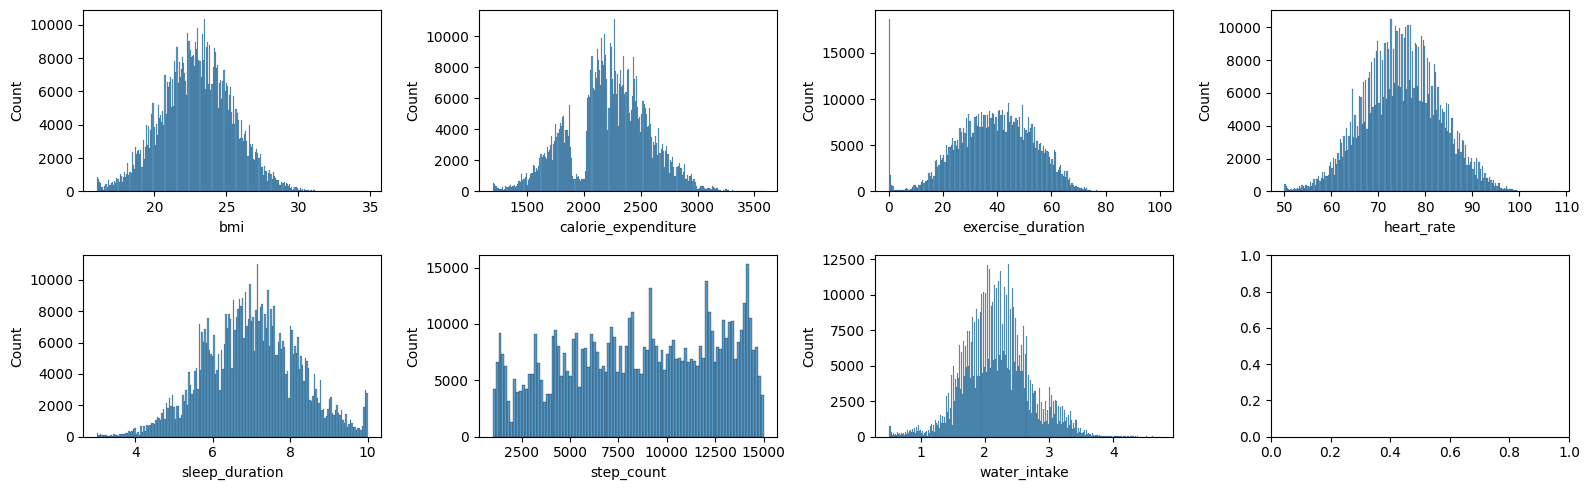

In [24]:
_, axes = plt.subplots(2, 4, figsize = (16, 5))
for i, ax in zip(X_num, axes.flatten()):
    sns.histplot(df_train, x = i, ax = ax)
plt.tight_layout()
plt.show()

- calorie_expenditur에 2000 부근에서 분포의 빈도가 급감한 인위적인 영역이 보인다.
- 데이터가 cliping 된 흔적으로 보인다.
> exercise_duration은 0의 빈도가 높다.
> sleep duration 에서는 10의 빈도가 높다.
- 분포의 밀도가 부자연스럽다.

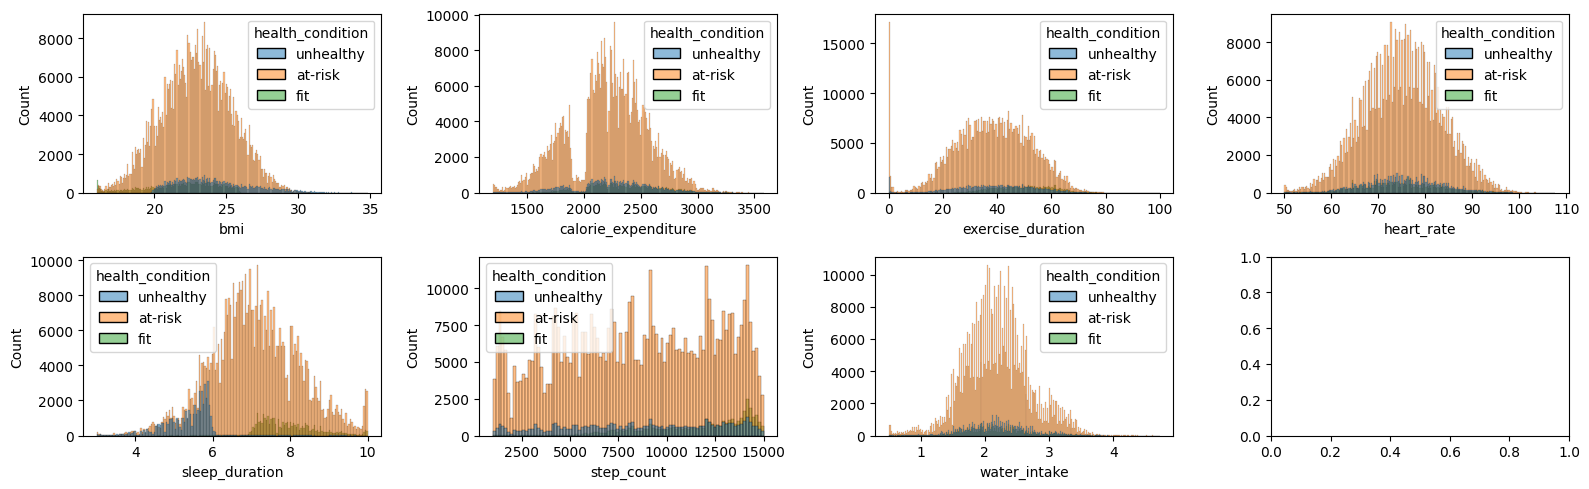

In [25]:
_, axes = plt.subplots(2, 4, figsize = (16, 5))
for i, ax in zip(X_num, axes.flatten()):
    sns.histplot(df_train, x = i, hue = target, ax = ax)
plt.tight_layout()
plt.show()

- calorie_expenditure와 sleep_duration에서 unhealthy와 fit 간의 확연한 구분점이 보인다.  

In [26]:
from scipy.stats import kruskal
pd.Series(
    [kruskal(*df_train.groupby(target)[i].agg(lambda x: list(x.dropna()))).pvalue for i in X_num], index = X_num,
    name = 'pvalue'
).sort_values(ascending=True).to_frame().T

,bmi,calorie_expenditure,exercise_duration,sleep_duration,step_count,heart_rate,water_intake
pvalue,0.0,0.0,0.0,0.0,0.0,4.365762e-23,7.381862e-09


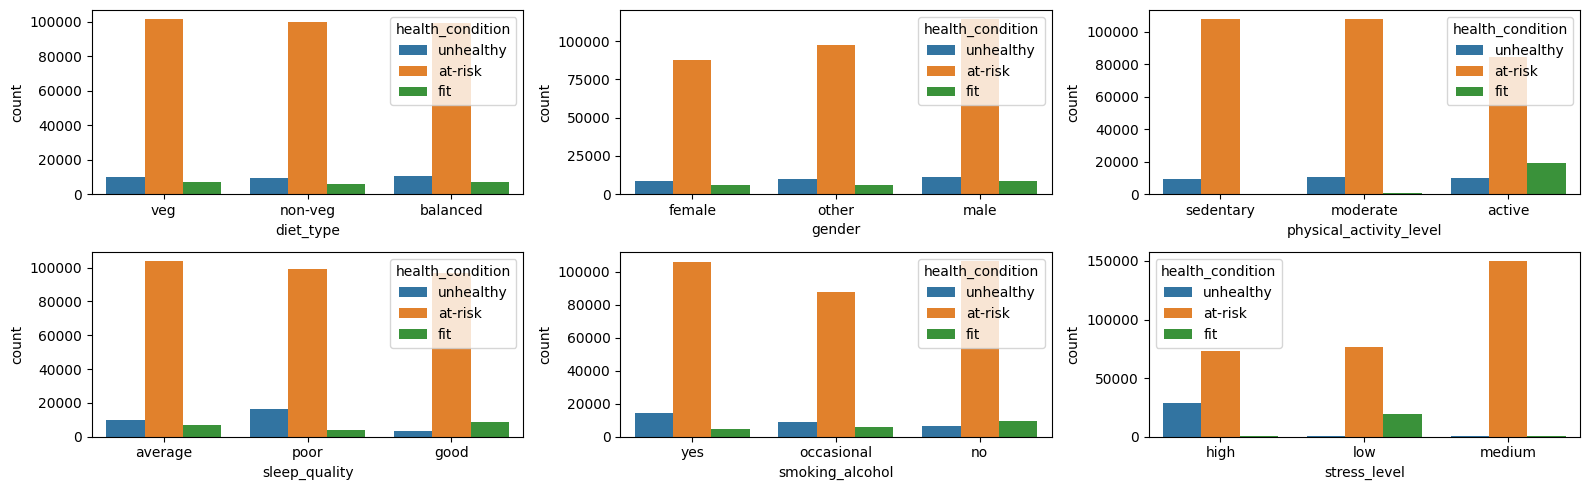

In [27]:
_, axes = plt.subplots(2, 3, figsize = (16, 5))
for i, ax in zip(X_cat, axes.flatten()):
    sns.countplot(df_train.dropna(), x = i, hue = target, ax = ax)
plt.tight_layout()
plt.show()

- stress level 만으로도 상당한 분리력이 보인다.
- sleep quality, physical_activity_level 분리력이 있다.
- 전부 3-state ordinal 변수라고도 할 수 있다.

In [28]:
from scipy.stats import chi2_contingency
df_train[X_cat].apply(
    lambda x: chi2_contingency(
        pd.crosstab(x, df_train[target])
    ).pvalue, axis = 0
).rename('pvalue').sort_values(ascending=True).to_frame().T

,sleep_quality,physical_activity_level,stress_level,smoking_alcohol,diet_type,gender
pvalue,0.0,0.0,0.0,0.0,1.117829e-68,3.895727e-48


- 결측치와의 연관성

In [29]:
df_train[X_cat + X_num].isna().apply(
    lambda x: chi2_contingency(pd.crosstab(x, df_train[target])).pvalue
).rename('pvalue').sort_values(ascending=True).iloc[:5].to_frame().T

,bmi,heart_rate,diet_type,water_intake,exercise_duration
pvalue,2.941930e-144,0.003861,0.036695,0.038828,0.172269


In [30]:
df_train[X_num].corr().unstack().reset_index([0, 1]).pipe(
    lambda x: x.loc[x['level_0'] < x['level_1']]
).pipe(
    lambda x: x.iloc[np.argsort(-x[0].abs())[:10]]
)

,level_0,level_1,0
19,exercise_duration,step_count,0.438236
12,calorie_expenditure,step_count,0.400102
9,calorie_expenditure,exercise_duration,0.393592
1,bmi,calorie_expenditure,0.117624
4,bmi,sleep_duration,-0.074576
5,bmi,step_count,-0.020548
2,bmi,exercise_duration,-0.020289
17,exercise_duration,heart_rate,-0.005679
26,heart_rate,step_count,-0.005486
25,heart_rate,sleep_duration,-0.005183


In [31]:
from scipy.stats import kruskal
from itertools import combinations, product

pd.DataFrame([
    (i, j, kruskal(*df_train.groupby(i)[j].agg(lambda x: list(x.dropna()))).pvalue)
    for i,j in product(X_cat, X_num)
], columns = ['v1', 'v2', 'pvalue']).sort_values('pvalue').iloc[:15]

,v1,v2,pvalue
15,physical_activity_level,calorie_expenditure,0.000000e+00
25,sleep_quality,sleep_duration,0.000000e+00
19,physical_activity_level,step_count,0.000000e+00
16,physical_activity_level,exercise_duration,0.000000e+00
39,stress_level,sleep_duration,0.000000e+00
35,stress_level,bmi,0.000000e+00
32,smoking_alcohol,sleep_duration,8.218143e-252
14,physical_activity_level,bmi,2.467052e-133
21,sleep_quality,bmi,6.037449e-72
28,smoking_alcohol,bmi,9.617630e-40


In [32]:
pd.DataFrame([
    (i, j, chi2_contingency(pd.crosstab(df_train[i], df_train[j])).pvalue)
    for i,j in combinations(X_cat, 2)
], columns = ['v1', 'v2', 'pvalue']).sort_values('pvalue').iloc[:15]

,v1,v2,pvalue
14,smoking_alcohol,stress_level,0.000000e+00
13,sleep_quality,stress_level,3.024848e-107
11,physical_activity_level,stress_level,1.518988e-95
10,physical_activity_level,smoking_alcohol,6.380717e-54
12,sleep_quality,smoking_alcohol,8.822753e-46
8,gender,stress_level,1.012831e-29
1,diet_type,physical_activity_level,3.716048e-28
4,diet_type,stress_level,6.962907e-27
0,diet_type,gender,6.263089e-24
5,gender,physical_activity_level,5.088984e-16


## Processing Missing values

In [10]:
df_fna = pd.concat(
    [df_train[X_num + X_cat], df_test[X_num + X_cat]]
)
s_ord_list = list()
X_ord = list()
for i, d in [
    ('diet_type', {'veg': -1, 'balanced': 0, 'non-veg': 1}),
    ('gender', {'female': -1, 'other': 0, 'male': 1}),
    ('physical_activity_level', {'sedentary': -1, 'moderate': 0, 'active': 1}),
    ('sleep_quality', {'poor': -1, 'average': 0, 'good': 1}),
    ('smoking_alcohol', {'no': -1, 'occasional': 0, 'yes': 1}),
    ('stress_level', {'low': -1, 'medium': 0, 'high': 1})]:
    s_ord_list.append(
        df_fna[i].cat.add_categories([-1, 0, 1]).replace(d).cat.remove_unused_categories().astype('float32').rename(i + '_o')
    )
    X_ord.append(i + '_o')
df_fna = df_fna.join(pd.concat(s_ord_list, axis=1))
df_fna['isna_bmi'] = df_fna['bmi'].isna()
df_fna['isna_heart_rate'] = df_fna['heart_rate'].isna()

In [11]:
import lightgbm as lgb
reg_lgb = lgb.LGBMRegressor(n_estimators = 300, random_state = 123, verbose=-1)
X_num_f2 = list()
s_na_list = list()
X_num_ord = X_num + X_ord
for i in df_fna[X_num_ord].isna().sum().sort_values().index:
    X_num_ord2 = [j for j in X_num_ord if j != i]
    reg_lgb = df_fna.loc[df_fna[i].notna()].pipe(
        lambda x: reg_lgb.fit(x[X_num_ord2], x[i])
    )
    s_na = df_fna[i].copy()
    bfna = s_na.isna()
    s_na.loc[bfna] = reg_lgb.predict(df_fna.loc[bfna, X_num_ord2]).astype('float32')
    s_na_list.append(s_na)
    X_num_f2.append(i + '_f')
X_ord_f = [i + '_f' for i in X_ord]
X_num_f = [i + '_f' for i in X_num]
df_fna = df_fna.join(pd.concat(s_na_list, axis=1).rename(columns = lambda x: x + '_f'))

In [12]:
s_na_list = list()
X_cat_f = list()
clf_lgb = lgb.LGBMClassifier(n_estimators = 300, random_state = 123, verbose=-1)
for i in df_fna[X_cat].isna().sum().sort_values().index:
    X_ord2 = [j + '_o' for j in X_cat if j != i]
    X_var = X_num + X_ord2
    clf_lgb = df_fna.loc[df_fna[i].notna()].pipe(
        lambda x: clf_lgb.fit(x[X_var], x[i])
    )
    s_na = df_fna[i]
    bfna = s_na.isna()
    s_na.loc[bfna] = clf_lgb.predict(df_fna.loc[bfna, X_var])
    s_na_list.append(s_na)
    X_cat_f.append(i + '_f2')
df_fna= df_fna.join(
    pd.concat(s_na_list, axis=1).rename(columns = lambda x: x + '_f2')
)

In [13]:
class_weight = df_train[target].value_counts().pipe(
    lambda x: x.min() / x
).to_dict()
class_weight

{'at-risk': 0.06717114356159112, 'unhealthy': 0.6895398794262352, 'fit': 1.0}

In [14]:
y = 'target_i'
y_repl = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
df_train = df_fna.loc[df_train.index].join(df_train[target]).assign(
    target_i = lambda x: x[target].map(y_repl).astype('int'),
    sample_weight = lambda x: x[target].map(class_weight).astype('float32')
)
df_test = df_fna.loc[df_test.index]

# ml-baseline

In [15]:
import mllabs
from sklearn.model_selection import ShuffleSplit
def dsl_str(v):
    if type(v) == str:
        return '{' + v + '}'
    return '{' + ','.join(v) + '}'
y_edges = {'y': dsl_str(y)}
prj = mllabs.Project('prj', df_train)
prj.set_experimenter(
    'explore', sp = ShuffleSplit(1, train_size = 0.8, random_state = 123), sp_v = ShuffleSplit(1, train_size = 0.8, random_state = 123),
    exist = 'skip'
)

I0000 00:00:1787473233.577736  159038 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787473233.613024  159038 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787473234.853810  159038 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will

In [16]:
prj.pipeline.set_grp('pre', method='transform')
prj.pipeline.set_node('std', grp='pre', processor='sklearn.preprocessing.StandardScaler', edges={'X': dsl_str(X_num_f)})
prj.pipeline.set_node('ohe', grp='pre', processor='sklearn.preprocessing.OneHotEncoder', edges={'X': dsl_str(X_cat_f)}, params={'sparse_output': False})
prj.publish_pipeline()
prj.build('explore')

No stage nodes to build


In [17]:
def conn(**kw):
    return {'__ref__': 'mllabs.Connector', '__params__': kw}
for name, connector, params in [
    ('xgb_evals_results', conn(processor='xgboost.XGBClassifier'), {'result_key': 'evals_result'}),
    ('lgb_evals_results', conn(processor='lightgbm.LGBMClassifier'), {'result_key': 'evals_result'}),
    ('cb_evals_results', conn(processor='catboost.CatBoostClassifier'), {'result_key': 'evals_result'}),
    ('nn_evals', conn(processor='mllabs.nn.NNClassifier'), {'result_key': 'evals_result'}),
    ('lgb_feature_importance', conn(processor='lightgbm.LGBMClassifier', edges=y_edges), {'result_key': 'feature_importances'}),
    ('xgb_feature_importance_gain', conn(processor='xgboost.XGBClassifier', edges=y_edges), {'result_key': 'feature_importances', 'params': {'importance_type': 'gain'}}),
    ('xgb_feature_importance_cover', conn(processor='xgboost.XGBClassifier', edges=y_edges),{'result_key': 'feature_importances', 'params': {'importance_type': 'cover'}}),
    ('cb_feature_importance', conn(processor='catboost.CatBoostClassifier', edges=y_edges), {'result_key': 'feature_importances_pvc'}),
    ('cb_interaction', conn(processor='catboost.CatBoostClassifier', edges=y_edges), {'result_key': 'feature_importances_interaction'}),
    ('lr_coef', conn(processor='sklearn.linear_model.LogisticRegression', edges=y_edges), {'result_key': 'coef'})]:    
    prj.set_collector('explore', name, 'mllabs.collector.ModelAttrCollector', connector, params=params)
prj.set_collector(
    'explore', 'bAcc', 'mllabs.collector.MetricCollector', conn(edges=y_edges),
    params={'output_var': None,
            'metric_func': {
            '__ref__': 'mllabs.collector.ProbToLabel',
            '__params__': {
                'metric_func': {'__callable__': 'sklearn.metrics.balanced_accuracy_score'},
                'var': '{target_i}',
                'thresholds': None # argmax — 필요하면 이진은 float, 다중클래스는 클래스별 list
            }
        }, 'include_train': True}, exist='replace')

In [18]:
tmp = prj.experimenters['explore'].get_train_data({
    'X': 'std:(*) + ohe:(*@ohe_drop_first)', 'y': dsl_str(y), 'sample_weight': dsl_str('sample_weight')
})

In [19]:
tmp['y'].data.value_counts()

target_i
0           379268
1            36929
2            25459
Name: count, dtype: int64

In [20]:
df_train[target].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [21]:
edges_boosting = {
    'X': dsl_str(X_num_ord), 'y': dsl_str(y)
}
baseline_models = [
    dict(
        processor='xgboost.XGBClassifier', 
        adapter={'__ref__': 'mllabs.adapter.XGBoostAdapter', '__params__': {'eval_mode': 'both'}},
        params={'random_state': 123, 'n_estimators': 10000, 'enable_categorical': True,
                'early_stopping_rounds': 50, 'eval_metric': 'mlogloss'},
        edges = edges_boosting,
        desc = 'XGBClassifier 베이스라인' 
    ),
    dict(
        processor='lightgbm.LGBMClassifier',
        adapter={'__ref__': 'mllabs.adapter.LightGBMAdapter', '__params__': {'eval_mode': 'both'}},
        params={'random_state': 123, 'n_estimators': 10000, 'verbose': -1, 'gpu': None,
                'early_stopping': {'stopping_rounds': 50, 'first_metric_only': True},
                'eval_metric': 'multi_logloss'},
        edges = edges_boosting,
        desc = 'LGBMClassifier 베이스라인' 
    ),
    dict(
        processor='catboost.CatBoostClassifier',
        adapter={'__ref__': 'mllabs.adapter.CatBoostAdapter', '__params__': {'eval_mode': 'valid'}},
        params={'random_state': 123, 'n_estimators': 10000, 'early_stopping_rounds': 50,
                'eval_metric': 'AUC', 'verbose': 0,
                'cat_features': {'__ref__': 'mllabs.ColSelector',
                                 '__params__': {'dsl_string': '*@categorical'}}},
        edges = edges_boosting,
        desc = 'CatBoostClassifier 베이스라인'
    ),
    dict(
        processor='mllabs.nn.NNClassifier',
        params={'hidden': {'units': [32, 16]}, 'metrics': ['sparse_categorical_crossentropy'], 'early_stopping': 10, 'epochs': 200}, 
        edges={'X': 'std:(*) + ohe:(*)', 'y': dsl_str(y)},
        desc = '신경망 베이스라인'
    ),
    dict(
        processor='sklearn.linear_model.LogisticRegression', params={}, 
        edges={'X': 'std:(*) + ohe:(*@ohe_drop_first)', 'y': dsl_str(y)},
        desc = '선형회귀 베이스라인'
    ),
]


In [22]:
from mllabs import ProgressSessionLogger, TqdmProgressSession
logger = ProgressSessionLogger(level=['info', 'progress'], session_cls=TqdmProgressSession)
kw = {'n_jobs': 2, 'gpu_id_list': [0], 'logger': logger}

In [21]:
prj.experimenters['explore'].collectors.get_collector('bAcc').get_metrics_agg()[0]

,test,train,valid
b11,0.333333,0.333333,0.333333
b12,0.333333,0.333333,0.333333
b13,0.333333,0.333333,0.333333
b14,0.333333,0.333333,0.333333
b15,0.333333,0.333333,0.333333
b21,0.879199,0.885441,0.874333
b22,0.875635,0.876204,0.870968
b23,0.876928,0.882495,0.871565
b24,0.894621,0.890131,0.892114
b25,0.867825,0.861572,0.862510


In [23]:
sample_weight_models = [
    {**d, 'edges': {**d['edges'], 'sample_weight': dsl_str('sample_weight')}, 'desc': d['desc'] + ' 차별적 표본가중치'}
    for d in baseline_models
]
trials = prj.make_trials('b', mllabs.ListTrials(sample_weight_models, method='predict_proba'))

In [24]:
prj.exp('explore', trials, **kw)

Experimenting 5 job(s)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

I0000 00:00:1787473261.962693  159660 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787473261.962845  159661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787473262.001290  159661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787473262.001296  159660 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions 

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	training's multi_logloss: 0.141397	valid_1's multi_logloss: 0.176112
Evaluated only: multi_logloss
Exp complete: 5 job(s)


In [25]:
prj.get_collector('explore', 'bAcc').get_metrics_agg()[0]

,test,train,valid
b11,0.333333,0.333333,0.333333
b12,0.333333,0.333333,0.333333
b13,0.333333,0.333333,0.333333
b14,0.333333,0.333333,0.333333
b15,0.333333,0.333333,0.333333
b21,0.879199,0.885441,0.874333
b22,0.875635,0.876204,0.870968
b23,0.876928,0.882495,0.871565
b24,0.894621,0.890131,0.892114
b25,0.867825,0.861572,0.862510


In [29]:
prj.trials.get_by_name('b42').get_spec()

<ProcessorSpec 'b42' processor='lightgbm.LGBMClassifier' method='predict_proba'>

In [28]:
prj.get_collector('explore', 'lgb_evals_results').get_attr('b47')

[[0    multi_logloss  training    0.934226
                      valid_1     0.934361
  1    multi_logloss  training    0.806299
                      valid_1     0.806530
  2    multi_logloss  training    0.704146
                                    ...   
  140  multi_logloss  valid_1     0.176549
  141  multi_logloss  training    0.128066
                      valid_1     0.176571
  142  multi_logloss  training    0.127837
                      valid_1     0.176558
  Length: 286, dtype: float64]]

In [38]:
prj.get_collector('explore', 'xgb_evals_results').get_attr('b36')

[[0   mlogloss  validation_0    0.164314
                validation_1    0.166823
  1   mlogloss  validation_0    2.564796
                validation_1    2.580466
  2   mlogloss  validation_0    0.187163
                                  ...   
  48  mlogloss  validation_1    0.224708
  49  mlogloss  validation_0    0.205521
                validation_1    0.225562
  50  mlogloss  validation_0    0.205531
                validation_1    0.225649
  Length: 102, dtype: float64]]